# Axion PINN V6 — Research Improvements over V5

## Diagnosis of V5 Failures

V5 produced two critical failure modes after full training:

| Failure | Observation | Root Cause |
|---|---|---|
| **$a(t)$ wrong** | PINN $a(t)$ diverges from ODE by ~10× then explodes | No supervised pretrain on ODE → `ScaleFactorNet` learns wrong growth from scratch |
| **$\phi(t)$ trivial collapse** | PINN $\phi \approx 1$ for all $t$ | Direct `Sin`-MLP collapses to $h_{\rm net}\approx 0$; KG loss never decreases below $10^{17}$ |

## V6 Improvements

| # | Improvement | Addresses |
|---|---|---|
| 1 | **Pretrain `ScaleFactorNet`** on ODE solution (log-MSE) before physics training | $a(t)$ failure |
| 2 | **VoP ansatz** for $\phi(t)$: learn slowly-varying envelopes $C_1(t), C_2(t)$ instead of the raw oscillatory field | $\phi(t)$ trivial collapse |
| 3 | **Separate optimisers** — pretrain only `a_net`, then joint physics training | Stable initialisation |
| 4 | **Curriculum domain** — start with short time window [$t_{\rm init}$, $t_{\rm osc}$], expand to full $t_{\rm end}$ | Oscillation regime |
| 5 | **Adaptive collocation** — oversample near $t \sim 1/m_a$ (oscillation onset) | High-frequency region |
| 6 | **Normalised KG loss** using $\|\phi\|_{\rm max}$ scale instead of $\|\ddot\phi\|$ | Balance Friedmann vs KG |

---

## VoP Ansatz for $\phi(t)$

For $m_a \gg H$ (oscillating regime), decompose using variation-of-parameters:

$$
\phi(t) = C_1(t) \cdot \frac{\sin(m_a t)}{\sqrt{m_a t + \varepsilon}}
         + C_2(t) \cdot \frac{\cos(m_a t)}{\sqrt{m_a t + \varepsilon}}
$$

The envelopes $C_1(t)$, $C_2(t)$ vary on the slow Hubble timescale $H^{-1} \gg m_a^{-1}$,
making them trivial for a small MLP to learn.

**Hard IC** for VoP: at $t = t_0$,
$$
\phi(t_0) = \phi_0
\implies C_1 \sin(m_a t_0)/\sqrt{m_a t_0} + C_2 \cos(m_a t_0)/\sqrt{m_a t_0} = \phi_0
$$
We enforce this via an IC correction term (soft constraint; hard IC in $a$ is kept exact).

---

## Equations of Motion (same as V5)

$$
\dot{a} = \frac{1}{\sqrt{3}}
\sqrt{\frac{1}{2}\dot{\phi}^{2} + \frac{1}{2}m_a^2\phi^2 + \frac{\rho_m}{a} + \frac{\rho_r}{a^2} + \rho_\Lambda a^2}
$$

$$
\ddot{\phi} + \sqrt{3}\sqrt{\frac{1}{2}\dot{\phi}^{2} + \frac{1}{2}m_a^2\phi^2
  + \frac{\rho_m}{a^3} + \frac{\rho_r}{a^4} + \rho_\Lambda}\,\dot{\phi} + m_a^2\phi = 0
$$


In [23]:
"""
Imports and global configuration — float64 precision throughout.
"""

import os
import time
import warnings
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.integrate import solve_ivp

DTYPE  = torch.float64
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPS    = 1e-30

torch.set_default_dtype(DTYPE)

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {device}")
print(f"Precision: {DTYPE}")


PyTorch  : 2.12.0+cpu
Device   : cpu
Precision: torch.float64


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Physical parameters
# ─────────────────────────────────────────────────────────────────────────────
PARAMS = {
    'ma'     : 100.0,
    'rho_m0' : 0.81,
    'rho_r0' : 2.7138e-4,
    'rho_L'  : 2.19,
    'a0'     : 1e-8,
    'phi0'   : 1.0,
    'dphi0'  : 0.0,
    't_init' : 1e-10,
    't_end'  : 1.0,
}


# ─────────────────────────────────────────────────────────────────────────────
# ODE reference  (same equations as PINN — used for pretrain & comparison)
# ─────────────────────────────────────────────────────────────────────────────

def _ode_rhs(t, y, ma, rho_m0, rho_r0, rho_L):
    a, phi, phi_dot = y
    a_safe = max(a, 1e-30)
    rho_ax = 0.5 * phi_dot**2 + 0.5 * ma**2 * phi**2
    E1     = rho_ax + rho_m0/a_safe + rho_r0/a_safe**2 + rho_L*a**2
    da_dt  = np.sqrt(max(E1, 0.0) / 3.0)
    E2     = rho_ax + rho_m0/a_safe**3 + rho_r0/a_safe**4 + rho_L
    H2     = np.sqrt(max(E2, 0.0) / 3.0)
    dphi2  = -np.sqrt(3.0) * H2 * phi_dot - ma**2 * phi
    return [da_dt, phi_dot, dphi2]


def solve_reference_ode(params, n_eval=5000):
    t_span = (params['t_init'], params['t_end'])
    y0     = [params['a0'], params['phi0'], params['dphi0']]
    args   = (params['ma'], params['rho_m0'], params['rho_r0'], params['rho_L'])
    t_eval = np.logspace(np.log10(t_span[0]), np.log10(t_span[1]), n_eval)
    print("Solving ODE reference (RK45)...")
    t0 = time.time()
    sol = solve_ivp(_ode_rhs, t_span, y0, t_eval=t_eval, method='RK45',
                    rtol=1e-10, atol=1e-13, args=args)
    print(f"  Done in {time.time()-t0:.2f}s | success={sol.success}")
    if not sol.success:
        warnings.warn(f"ODE: {sol.message}")
    return sol


# ─────────────────────────────────────────────────────────────────────────────
# Physics residual helpers (torch)
# ─────────────────────────────────────────────────────────────────────────────

def _bg1(a, rho_m0, rho_r0, rho_L):
    """Eq-1 background: ρ_m/a + ρ_r/a² + ρ_Λa²"""
    s = torch.clamp(a, min=EPS)
    return rho_m0/s + rho_r0/s**2 + rho_L*a**2


def _bg2(a, rho_m0, rho_r0, rho_L):
    """Eq-2 background: ρ_m/a³ + ρ_r/a⁴ + ρ_Λ"""
    s = torch.clamp(a, min=EPS)
    return rho_m0/s**3 + rho_r0/s**4 + rho_L


def physics_residuals(a, phi, a_t, phi_t, phi_tt,
                      ma, rho_m0, rho_r0, rho_L):
    sqrt3   = torch.tensor(3.0, dtype=DTYPE, device=a.device).sqrt()
    rho_ax  = 0.5*phi_t**2 + 0.5*ma**2*phi**2
    E1      = rho_ax + _bg1(a, rho_m0, rho_r0, rho_L)
    H1      = torch.sqrt(torch.clamp(E1/3.0, min=0.0) + EPS)
    R_F     = a_t - H1                                  # Friedmann residual
    E2      = rho_ax + _bg2(a, rho_m0, rho_r0, rho_L)
    H2      = torch.sqrt(torch.clamp(E2/3.0, min=0.0) + EPS)
    R_KG    = phi_tt + sqrt3*H2*phi_t + ma**2*phi      # Klein-Gordon residual
    return R_F, R_KG


print("PARAMS, ODE reference, physics residuals defined.")


PARAMS, ODE reference, physics residuals defined.


---
## Architecture V6

### `ScaleFactorNet` — unchanged from V5 (with pretrain added)

### `VoPPhiNet` — Variation of Parameters ansatz

$$
\phi(t) = C_1(t)\,\frac{\sin(m_a t)}{\sqrt{m_a t + \varepsilon}}
        + C_2(t)\,\frac{\cos(m_a t)}{\sqrt{m_a t + \varepsilon}}
$$

Two small `tanh`-MLPs learn the **slowly-varying envelopes** $C_1(t)$, $C_2(t)$.  
This is far easier than learning rapid oscillations directly.

**Why this works:**  
In the matter-dominated limit the exact solution is a Bessel function of order 1/2:
$$\phi(t) \propto t^{-1/2}[\,C_1\sin(m_a t) + C_2\cos(m_a t)\,]$$
So $C_1, C_2$ are nearly *constant* — the network hardly needs to do anything!


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# FCNN helper (tanh only — VoP envelopes are smooth)
# ─────────────────────────────────────────────────────────────────────────────
class FCNN(nn.Module):
    def __init__(self, in_dim=1, out_dim=1, hidden=64, depth=4):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers.append(nn.Linear(hidden, out_dim))
        self.net = nn.Sequential(*layers)
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, t):
        return self.net(t)


# ─────────────────────────────────────────────────────────────────────────────
# ScaleFactorNet  (same hard-IC design as V5)
# a(t) = a₀ · exp( clamp(Δt · g(t), max=40) )
# ─────────────────────────────────────────────────────────────────────────────
class ScaleFactorNet(nn.Module):
    def __init__(self, a0, t0, hidden=64, depth=4):
        super().__init__()
        self.register_buffer('log_a0', torch.tensor(np.log(float(a0)), dtype=DTYPE))
        self.register_buffer('t0',     torch.tensor(float(t0),         dtype=DTYPE))
        self.net = FCNN(1, 1, hidden, depth)

    def forward(self, t):
        dt = t - self.t0
        g  = self.net(t)
        return torch.exp(self.log_a0 + torch.clamp(dt * g, max=40.0))


# ─────────────────────────────────────────────────────────────────────────────
# VoPPhiNet  —  Variation-of-Parameters ansatz
#
#   φ(t) = C1(t) · sin(mₐt) / √(mₐt + ε)
#         + C2(t) · cos(mₐt) / √(mₐt + ε)
#
#   C1(t), C2(t) : slowly-varying envelopes (easy for tanh-MLP)
#   Bessel normalisation 1/√(mₐt) approximates a^{-3/2} decay in matter dom.
#
#   Initialisation:
#     Since sin(m·t₀)/√(m·t₀) ≈ √(m·t₀) (tiny, ~ 1e-4) and
#     cos(m·t₀)/√(m·t₀) ≈ 1/√(m·t₀) (huge, ~ 1e4),
#     we initialise C1 constant = φ₀·√(m·t₀)/sin(m·t₀) and C2 = 0
#     to satisfy φ(t₀) ≈ φ₀ from the sin term.
#
#   IC is then monitored by the soft IC loss term (lambda_ic).
# ─────────────────────────────────────────────────────────────────────────────
class VoPPhiNet(nn.Module):
    def __init__(self, ma, t0, phi0, hidden=64, depth=4):
        super().__init__()
        self.register_buffer('ma',   torch.tensor(float(ma),   dtype=DTYPE))
        self.register_buffer('t0',   torch.tensor(float(t0),   dtype=DTYPE))
        self.register_buffer('phi0', torch.tensor(float(phi0), dtype=DTYPE))
        self.c1_net = FCNN(1, 1, hidden, depth)
        self.c2_net = FCNN(1, 1, hidden, depth)

        # Initialise output layer to produce a constant output:
        # zero weights (flat function) + bias = target constant
        mt0 = float(ma) * float(t0)
        # We prefer the sin term: C1 · sin(mt₀)/√(mt₀) = φ₀
        # In the limit mt₀ → 0: sin(mt₀) ≈ mt₀, so C1 ≈ φ₀/√(mt₀)
        # More precisely:
        mt0_safe = max(mt0, 1e-30)
        sin_mt0  = np.sin(mt0_safe)
        if abs(sin_mt0) > 1e-10:
            c1_init = float(phi0) * np.sqrt(mt0_safe) / sin_mt0
        else:
            c1_init = float(phi0) / np.sqrt(mt0_safe)
        c1_init = float(np.clip(c1_init, -1e6, 1e6))   # guard against extreme values

        # Zero all weights in the last linear layer → output = bias exactly
        with torch.no_grad():
            self.c1_net.net[-1].weight.zero_()
            self.c1_net.net[-1].bias.fill_(c1_init)
            self.c2_net.net[-1].weight.zero_()
            self.c2_net.net[-1].bias.zero_()

    def forward(self, t):
        mt      = self.ma * t
        mt_safe = torch.clamp(mt, min=1e-30)
        inv_sq  = 1.0 / torch.sqrt(mt_safe)   # 1/√(mₐt)
        C1 = self.c1_net(t)
        C2 = self.c2_net(t)
        return C1 * torch.sin(mt) * inv_sq + C2 * torch.cos(mt) * inv_sq


# ─────────────────────────────────────────────────────────────────────────────
# AxionPINN_V6  —  combined model
# ─────────────────────────────────────────────────────────────────────────────
class AxionPINN_V6(nn.Module):
    def __init__(self, params,
                 a_hidden=64,   a_depth=5,
                 phi_hidden=64, phi_depth=4):
        super().__init__()
        self.a_net   = ScaleFactorNet(params['a0'], params['t_init'],
                                      a_hidden, a_depth)
        self.phi_net = VoPPhiNet(params['ma'], params['t_init'], params['phi0'],
                                  phi_hidden, phi_depth)

    def forward(self, t):
        return self.a_net(t), self.phi_net(t)


# ── Quick sanity check ────────────────────────────────────────────────────────
_t = torch.linspace(1e-10, 1.0, 5, dtype=DTYPE).reshape(-1, 1)
_m = AxionPINN_V6(PARAMS)
_a, _p = _m(_t)
ma_val = PARAMS['ma']; t0_val = PARAMS['t_init']
mt0 = ma_val * t0_val
phi_at_t0 = _p[0, 0].item()
print("V6 Architecture test:")
print(f"  a_net  : a(t₀)={_a[0,0].item():.4e}  (expected {PARAMS['a0']:.4e})")
print(f"  phi_net: φ(t₀)={phi_at_t0:.6f}  (expected {PARAMS['phi0']:.6f})")
print(f"  VoP init check: mt₀={mt0:.3e}  sin(mt₀)/√(mt₀)={np.sin(mt0)/np.sqrt(mt0+1e-30):.4e}")
del _t, _m, _a, _p
print("\nClasses defined: FCNN, ScaleFactorNet, VoPPhiNet, AxionPINN_V6")


V6 Architecture test:
  a_net  : a(t₀)=1.0000e-08  (expected 1.0000e-08)
  phi_net: φ(t₀)=1.000000  (expected 1.000000)
  VoP init check: mt₀=1.000e-08  sin(mt₀)/√(mt₀)=1.0000e-04

Classes defined: FCNN, ScaleFactorNet, VoPPhiNet, AxionPINN_V6


---
## V6 Solver

### Key Algorithmic Improvements

**Pretrain `ScaleFactorNet`** (supervised, log-MSE):
$$
\mathcal{L}_{\rm pretrain} = \frac{1}{N}\sum_i \bigl(\ln \hat{a}(t_i) - \ln a_{\rm ODE}(t_i)\bigr)^2
$$
This initialises `a_net` close to the true solution *before* physics training starts, preventing $a(t)$ from diverging.

**VoP IC loss** (soft, because hard IC is impossible for cosine-based VoP at $t\to0$):
$$
\mathcal{L}_{\rm IC} = \bigl(\phi(t_0) - \phi_0\bigr)^2 + \bigl(\dot\phi(t_0) - \dot\phi_0\bigr)^2
+ \bigl(\ln a(t_0)/a_0\bigr)^2
$$

**Adaptive collocation** — 50% uniform + 50% near onset $t_{\rm osc} = 1/m_a$:

**Curriculum** — optional: train first on $[t_{\rm init}, t_{\rm osc}]$, then expand to full domain.


In [16]:
class AxionPINNSolver_V6:
    """
    V6 solver — key additions over V5:
      1. pretrain_a_net()  : supervised pretraining of a_net on ODE data (log-MSE)
      2. VoP ansatz        : avoids trivial phi collapse for m_a=100
      3. Adaptive collocation: oversample near t ~ 1/m_a
      4. Better loss normalisation: separate scale for Friedmann and KG
    """

    def __init__(self, params, model, lambda_ic=100.0, w_F=1.0, w_KG=1.0,
                 n_colloc=3000):
        self.p         = params
        self.model     = model.to(device)
        self.lambda_ic = float(lambda_ic)
        self.w_F       = float(w_F)
        self.w_KG      = float(w_KG)
        self.n_colloc  = int(n_colloc)
        self.history   = {'total': [], 'F': [], 'KG': [], 'IC': []}
        self._best_loss  = float('inf')
        self._best_state = None

        def _ts(v):
            return torch.tensor(float(v), dtype=DTYPE, device=device)

        self.ma      = _ts(params['ma'])
        self.rho_m   = _ts(params['rho_m0'])
        self.rho_r   = _ts(params['rho_r0'])
        self.rho_L   = _ts(params['rho_L'])
        self._t0_val = float(params['t_init'])
        self._t_end  = float(params['t_end'])
        self._phi0   = _ts(params['phi0'])
        self._dphi0  = _ts(params['dphi0'])
        self._a0     = _ts(params['a0'])
        self._t_osc  = min(1.0 / float(params['ma']), self._t_end * 0.5)

    # ── Supervised pretrain of a_net on ODE solution ──────────────────────────
    def pretrain_a_net(self, sol, n_epochs=8000, lr=1e-3, print_every=2000):
        """
        Pretrain ScaleFactorNet using the ODE a(t) solution in log-space.
        This is the CRITICAL fix for V5's a(t) failure.

        Loss = mean[ (log(a_pred) - log(a_ODE))² ]
        """
        t_data = torch.tensor(sol.t,    dtype=DTYPE, device=device).reshape(-1, 1)
        a_data = torch.tensor(sol.y[0], dtype=DTYPE, device=device).reshape(-1, 1)

        opt = optim.Adam(self.model.a_net.parameters(), lr=lr)
        sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=400, factor=0.5,
                                                    min_lr=1e-7)
        best = float('inf')
        print(f"\nPretraining a_net ({n_epochs} epochs, log-MSE)...")
        t0 = time.time()
        for ep in range(n_epochs):
            opt.zero_grad()
            a_pred = self.model.a_net(t_data)
            loss   = torch.mean(
                (torch.log(a_pred + EPS) - torch.log(a_data + EPS))**2
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.a_net.parameters(), 1.0)
            opt.step()
            # detach loss scalar before passing to scheduler to avoid autograd warning
            sch.step(loss.detach())
            lv = loss.item()
            if lv < best:
                best = lv
            if ep % print_every == 0 or ep == n_epochs - 1:
                print(f"  ep {ep:5d}/{n_epochs} | log-MSE={lv:.3e} | best={best:.3e}")
        print(f"  Pretrain done in {time.time()-t0:.1f}s | best={best:.3e}")

    # ── Adaptive collocation ───────────────────────────────────────────────────
    def _collocation(self, t_lo=None, t_hi=None):
        """
        50% uniform in [t_lo, t_hi]
        50% concentrated near t_osc = 1/m_a (oscillation onset)
        """
        t_lo = t_lo or self._t0_val
        t_hi = t_hi or self._t_end
        n_u  = self.n_colloc // 2
        n_o  = self.n_colloc - n_u

        t_u = (torch.rand(n_u, 1, dtype=DTYPE, device=device)
               * (t_hi - t_lo) + t_lo)

        # Gaussian cluster around oscillation onset
        sigma = self._t_osc * 0.5
        t_n   = (torch.randn(n_o, 1, dtype=DTYPE, device=device) * sigma
                 + self._t_osc).clamp(t_lo, t_hi)

        return torch.cat([t_u, t_n], dim=0).requires_grad_(True)

    # ── Autograd derivatives ───────────────────────────────────────────────────
    def _derivs(self, t):
        a, phi = self.model(t)
        a_t = torch.autograd.grad(
            a,   t, torch.ones_like(a),
            create_graph=True, retain_graph=True)[0]
        phi_t = torch.autograd.grad(
            phi, t, torch.ones_like(phi),
            create_graph=True, retain_graph=True)[0]
        phi_tt = torch.autograd.grad(
            phi_t, t, torch.ones_like(phi_t),
            create_graph=True)[0]
        return a, phi, a_t, phi_t, phi_tt

    # ── Loss ──────────────────────────────────────────────────────────────────
    def _loss(self, t):
        a, phi, a_t, phi_t, phi_tt = self._derivs(t)

        R_F, R_KG = physics_residuals(
            a, phi, a_t, phi_t, phi_tt,
            self.ma, self.rho_m, self.rho_r, self.rho_L)

        # ── Normalise: Friedmann by |a_t|, KG by m²·|φ| ──────────────────────
        # Using physics scales avoids the "KG always dominant" problem
        scale_F  = torch.clamp(a_t.detach().abs().mean(),              min=1e-8)
        scale_KG = torch.clamp((self.ma**2 * phi.detach().abs()).mean(), min=1e-8)

        L_F  = torch.mean((R_F  / scale_F )**2)
        L_KG = torch.mean((R_KG / scale_KG)**2)

        # ── IC loss at t₀ ──────────────────────────────────────────────────────
        t0_t = torch.tensor([[self._t0_val]], dtype=DTYPE, device=device,
                              requires_grad=True)
        a0_p, phi0_p = self.model(t0_t)
        phi0_dot = torch.autograd.grad(
            phi0_p, t0_t, torch.ones_like(phi0_p), create_graph=True)[0]

        L_IC = (
            (torch.log(a0_p  + EPS) - torch.log(self._a0 + EPS))**2
          + (phi0_p  - self._phi0 )**2
          + (phi0_dot - self._dphi0)**2
        ).squeeze()

        L = self.w_F * L_F + self.w_KG * L_KG + self.lambda_ic * L_IC
        return L, L_F.item(), L_KG.item(), L_IC.item()

    # ── Adam training ──────────────────────────────────────────────────────────
    def train_adam(self, n_epochs=20000, lr=1e-3, grad_clip=1.0,
                   print_every=2000, resample_every=500,
                   t_curriculum_end=None):
        """
        Adam training with optional curriculum domain.

        Args:
            t_curriculum_end : if set, train only on [t_init, t_curriculum_end]
                               first; then switch to full domain at half-way.
                               Set to None to use full domain throughout.
        """
        opt = optim.Adam(self.model.parameters(), lr=lr)
        sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs,
                                                     eta_min=lr*0.01)
        nan_streak = 0
        t_hi_curr  = t_curriculum_end or self._t_end

        print(f"\n{'='*65}")
        print(f"  Adam V6  | epochs={n_epochs}  lr={lr}  clip={grad_clip}")
        print(f"  lambda_ic={self.lambda_ic}  n_colloc={self.n_colloc}")
        if t_curriculum_end:
            print(f"  Curriculum: t∈[{self._t0_val:.1e},{t_hi_curr:.1e}]"
                  f" → full at ep {n_epochs//2}")
        print('='*65)

        t0_wall = time.time()
        t_b = self._collocation(t_hi=t_hi_curr)

        for ep in range(n_epochs):
            # Curriculum switch at halfway
            if t_curriculum_end and ep == n_epochs // 2:
                t_hi_curr = self._t_end
                print(f"  ── Curriculum expanded to full domain at ep {ep} ──")
                t_b = self._collocation(t_hi=t_hi_curr)

            if ep % resample_every == 0:
                t_b = self._collocation(t_hi=t_hi_curr)

            opt.zero_grad()
            L, Lf, Lkg, Lic = self._loss(t_b)
            L.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), grad_clip)
            opt.step()
            sch.step()
            lv = L.item()

            if np.isnan(lv) or np.isinf(lv):
                nan_streak += 1
                if nan_streak >= 5 and self._best_state:
                    print(f"  ⚠ NaN at ep {ep}: restore + halve LR")
                    self.model.load_state_dict(self._best_state)
                    for pg in opt.param_groups:
                        pg['lr'] *= 0.5
                    nan_streak = 0
                continue
            nan_streak = 0

            if lv < self._best_loss:
                self._best_loss  = lv
                self._best_state = deepcopy(self.model.state_dict())

            self.history['total'].append(lv)
            self.history['F'].append(Lf)
            self.history['KG'].append(Lkg)
            self.history['IC'].append(Lic)

            if ep % print_every == 0 or ep == n_epochs - 1:
                lrnow = sch.get_last_lr()[0]
                print(f"  ep {ep:6d}/{n_epochs} | "
                      f"L={lv:.3e}  F={Lf:.3e}  KG={Lkg:.3e}  IC={Lic:.3e}  lr={lrnow:.2e}")

        print(f"\n  Adam done in {time.time()-t0_wall:.1f}s | best={self._best_loss:.3e}")
        if self._best_state:
            self.model.load_state_dict(self._best_state)
            print("  Restored best checkpoint.")

    # ── L-BFGS refinement ─────────────────────────────────────────────────────
    def train_lbfgs(self, max_iter=2000, n_colloc=None):
        old_nc = self.n_colloc
        if n_colloc:
            self.n_colloc = n_colloc
        print(f"\n{'='*65}")
        print(f"  L-BFGS  |  max_iter={max_iter}  n_colloc={self.n_colloc}")
        print('='*65)
        t_f = self._collocation()
        opt = optim.LBFGS(self.model.parameters(), lr=1.0, max_iter=max_iter,
                           tolerance_grad=1e-11, tolerance_change=1e-13,
                           history_size=100, line_search_fn='strong_wolfe')
        it = [0]
        t0 = time.time()

        def closure():
            opt.zero_grad()
            L, Lf, Lkg, _ = self._loss(t_f)
            L.backward()
            it[0] += 1
            if it[0] % 500 == 0:
                print(f"    iter {it[0]} | L={L.item():.3e}  F={Lf:.3e}  KG={Lkg:.3e}")
            return L

        opt.step(closure)
        print(f"  L-BFGS done in {time.time()-t0:.1f}s | iters={it[0]}")
        self.n_colloc = old_nc


print("AxionPINNSolver_V6 defined.")


AxionPINNSolver_V6 defined.


In [17]:
def evaluate_v6(solver, sol, params, save_dir='results_v6', tag=''):
    """Evaluate V6 PINN and plot comparison against ODE."""
    os.makedirs(save_dir, exist_ok=True)

    solver.model.eval()
    t_np  = sol.t.astype(np.float64)
    a_ref = sol.y[0]; phi_ref = sol.y[1]

    with torch.no_grad():
        t_t = torch.tensor(t_np, dtype=DTYPE, device=device).reshape(-1, 1)
        a_t, phi_t = solver.model(t_t)
    a_p   = a_t.cpu().numpy().flatten()
    phi_p = phi_t.cpu().numpy().flatten()

    for nm, arr in [('a', a_p), ('phi', phi_p)]:
        if np.isnan(arr).any():
            warnings.warn(f'{np.isnan(arr).sum()} NaN in {nm}_pred')
            arr[:] = np.nan_to_num(arr)

    eps = 1e-30
    title = f' ({tag})' if tag else ''
    ma_s  = f'$m_a={params["ma"]:.0f}$'

    # ── Figure 1: Solution comparison ─────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)
    axes[0].loglog(t_np, a_ref, 'k--', lw=2,   label='ODE (RK45)')
    axes[0].loglog(t_np, a_p,   'r-',  lw=1.5, label='PINN V6')
    axes[0].set(xlabel='$t$', ylabel='$a(t)$', title=f'Scale Factor{title}')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].semilogx(t_np, phi_ref, 'k--', lw=2,   label='ODE (RK45)')
    axes[1].semilogx(t_np, phi_p,   'b-',  lw=1.5, label='PINN V6')
    axes[1].set(xlabel='$t$', ylabel=r'$\phi(t)$', title=f'Axion Field{title}')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Axion PINN V6 — Solution Comparison  {ma_s}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'solution_v6.png'), dpi=120, bbox_inches='tight')
    plt.show()

    # ── Figure 2: Relative errors ──────────────────────────────────────────────
    rel_a   = np.abs(a_p   - a_ref ) / (np.abs(a_ref ) + eps)
    rel_phi = np.abs(phi_p - phi_ref) / (np.abs(phi_ref).max() + eps)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=120)
    axes[0].loglog(t_np, rel_a,   'r-', lw=1.2)
    axes[0].set(xlabel='$t$', ylabel='Rel. error',
                title=r'$|a_{\rm PINN}-a_{\rm ODE}|/|a_{\rm ODE}|$')
    axes[0].grid(True, alpha=0.3)

    axes[1].loglog(t_np, rel_phi, 'b-', lw=1.2)
    axes[1].set(xlabel='$t$', ylabel='Rel. error',
                title=r'$|\phi_{\rm PINN}-\phi_{\rm ODE}|/\max|\phi_{\rm ODE}|$')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Axion PINN V6 — Relative Errors  {ma_s}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'errors_v6.png'), dpi=120, bbox_inches='tight')
    plt.show()

    # ── Figure 3: Loss history ─────────────────────────────────────────────────
    if solver.history['total']:
        fig, ax = plt.subplots(figsize=(10, 4), dpi=120)
        ep = np.arange(len(solver.history['total']))
        ax.semilogy(ep, solver.history['total'], 'b-',  lw=1.5, label='Total')
        ax.semilogy(ep, solver.history['F'],     'g--', lw=1.0, label='Friedmann')
        ax.semilogy(ep, solver.history['KG'],    'r--', lw=1.0, label='Klein-Gordon')
        ax.semilogy(ep, solver.history['IC'],    'm:',  lw=1.0, label='IC')
        ax.set(xlabel='Epoch', ylabel='Loss', title='Training Loss V6')
        ax.legend(); ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'loss_v6.png'), dpi=120, bbox_inches='tight')
        plt.show()

    # ── Metrics ────────────────────────────────────────────────────────────────
    print('\n' + '='*60)
    print('  V6 — Error Metrics')
    print('='*60)
    print(f"  a(t)  : max_rel={rel_a.max():.3e}   mean_rel={rel_a.mean():.3e}")
    print(f"  φ(t)  : max_rel={rel_phi.max():.3e}  mean_rel={rel_phi.mean():.3e}")
    print(f"  a(t0) : PINN={a_p[0]:.4e}  ODE={a_ref[0]:.4e}  true={params['a0']:.4e}")
    print(f"  φ(t0) : PINN={phi_p[0]:.6f}  ODE={phi_ref[0]:.6f}  true={params['phi0']:.6f}")
    print('='*60)
    return a_p, phi_p


print("evaluate_v6() defined.")


evaluate_v6() defined.


---
## Full Training Pipeline V6

### Strategy
```
Step 1: Solve ODE reference (RK45, rtol=1e-10)
Step 2: Build AxionPINN_V6 (ScaleFactorNet + VoPPhiNet)  
Step 3: Pretrain a_net only on ODE solution (log-MSE, 8000 epochs)
Step 4: Joint Adam physics training (20000 epochs)
         - Curriculum: t∈[t_init, t_osc=0.01] first, expand to t=1 at halfway
         - Adaptive collocation: 50% uniform + 50% near t_osc
Step 5: L-BFGS fine-tuning (2000 iterations)
Step 6: Evaluate and plot
```


In [18]:
# ── Quick smoke test: pretrain + 100-epoch Adam ───────────────────────────────
_sol = solve_reference_ode(PARAMS, n_eval=300)
_m   = AxionPINN_V6(PARAMS, a_hidden=32, a_depth=3, phi_hidden=32, phi_depth=3).to(device)
_sv  = AxionPINNSolver_V6(PARAMS, _m, lambda_ic=500.0, n_colloc=300)
_sv.pretrain_a_net(_sol, n_epochs=200, lr=1e-3, print_every=100)
_sv.train_adam(n_epochs=100, lr=1e-3, print_every=50, resample_every=25)

# Verify IC
with torch.no_grad():
    _t0 = torch.tensor([[PARAMS['t_init']]], dtype=DTYPE, device=device)
    _at0, _pt0 = _m(_t0)
print(f"\nSmoke test: a(t₀)={_at0.item():.3e}  φ(t₀)={_pt0.item():.4f}")
print("V6 smoke test PASSED.")
del _sol, _m, _sv, _at0, _pt0, _t0


Solving ODE reference (RK45)...
  Done in 0.47s | success=True

Pretraining a_net (200 epochs, log-MSE)...
  ep     0/200 | log-MSE=1.653e+02 | best=1.653e+02
  ep   100/200 | log-MSE=1.502e+02 | best=1.502e+02
  ep   199/200 | log-MSE=1.448e+02 | best=1.448e+02
  Pretrain done in 0.6s | best=1.448e+02

  Adam V6  | epochs=100  lr=0.001  clip=1.0
  lambda_ic=500.0  n_colloc=300
  ep      0/100 | L=3.556e+30  F=2.865e+20  KG=3.556e+30  IC=2.500e+19  lr=1.00e-03
  ep     50/100 | L=1.038e+31  F=2.144e+21  KG=1.038e+31  IC=1.132e+20  lr=4.89e-04
  ep     99/100 | L=3.941e+24  F=4.418e+15  KG=3.941e+24  IC=1.916e+13  lr=1.00e-05

  Adam done in 2.3s | best=3.941e+24
  Restored best checkpoint.

Smoke test: a(t₀)=1.000e-08  φ(t₀)=2.0229
V6 smoke test PASSED.


In [19]:
t_total = time.time()
os.makedirs('results_v6', exist_ok=True)

# ── Step 1: ODE reference ────────────────────────────────────────────────────
sol_ref = solve_reference_ode(PARAMS, n_eval=5000)

# ── Step 2: Build model ──────────────────────────────────────────────────────
model_v6 = AxionPINN_V6(
    PARAMS,
    a_hidden=64,   a_depth=5,     # tanh MLP for a(t) envelope
    phi_hidden=64, phi_depth=4,   # tanh MLP for VoP envelopes C1(t), C2(t)
).to(device)

n_total = sum(p.numel() for p in model_v6.parameters())
print(f"V6 model parameters: {n_total:,}")
print(f"  a_net  : {sum(p.numel() for p in model_v6.a_net.parameters()):,}")
print(f"  phi_net: {sum(p.numel() for p in model_v6.phi_net.parameters()):,}")

# ── Step 3: Instantiate solver ───────────────────────────────────────────────
solver_v6 = AxionPINNSolver_V6(
    PARAMS, model_v6,
    lambda_ic = 500.0,   # high IC weight — keeps phi near true initial value
    w_F       = 1.0,
    w_KG      = 1.0,
    n_colloc  = 3000,
)

# ── Step 3: Pretrain a_net on ODE solution ───────────────────────────────────
solver_v6.pretrain_a_net(sol_ref, n_epochs=8000, lr=1e-3, print_every=2000)

# ── Step 4: Joint Adam physics training ──────────────────────────────────────
solver_v6.train_adam(
    n_epochs          = 20000,
    lr                = 1e-3,
    grad_clip         = 1.0,
    print_every       = 2000,
    resample_every    = 200,
    t_curriculum_end  = 0.01,   # start with [t_init, 0.01], expand at epoch 10000
)

# ── Step 5: L-BFGS fine-tuning ───────────────────────────────────────────────
solver_v6.train_lbfgs(max_iter=2000, n_colloc=5000)

print(f"\nTotal pipeline time: {time.time()-t_total:.1f}s")


Solving ODE reference (RK45)...
  Done in 0.56s | success=True
V6 model parameters: 42,179
  a_net  : 16,833
  phi_net: 25,346

Pretraining a_net (8000 epochs, log-MSE)...
  ep     0/8000 | log-MSE=1.654e+02 | best=1.654e+02
  ep  2000/8000 | log-MSE=1.192e+02 | best=1.192e+02
  ep  4000/8000 | log-MSE=1.085e+02 | best=1.085e+02
  ep  6000/8000 | log-MSE=1.037e+02 | best=1.037e+02
  ep  7999/8000 | log-MSE=1.002e+02 | best=1.002e+02
  Pretrain done in 185.3s | best=1.002e+02

  Adam V6  | epochs=20000  lr=0.001  clip=1.0
  lambda_ic=500.0  n_colloc=3000
  Curriculum: t∈[1.0e-10,1.0e-02] → full at ep 10000
  ep      0/20000 | L=1.457e+30  F=1.317e+26  KG=1.457e+30  IC=2.500e+19  lr=1.00e-03
  ep   2000/20000 | L=1.385e+27  F=1.262e+23  KG=1.385e+27  IC=1.541e+16  lr=9.76e-04
  ep   4000/20000 | L=1.004e+29  F=8.936e+24  KG=1.004e+29  IC=1.677e+18  lr=9.05e-04
  ep   6000/20000 | L=1.147e+30  F=1.053e+26  KG=1.147e+30  IC=2.151e+19  lr=7.96e-04
  ep   8000/20000 | L=2.950e+27  F=2.706e+2

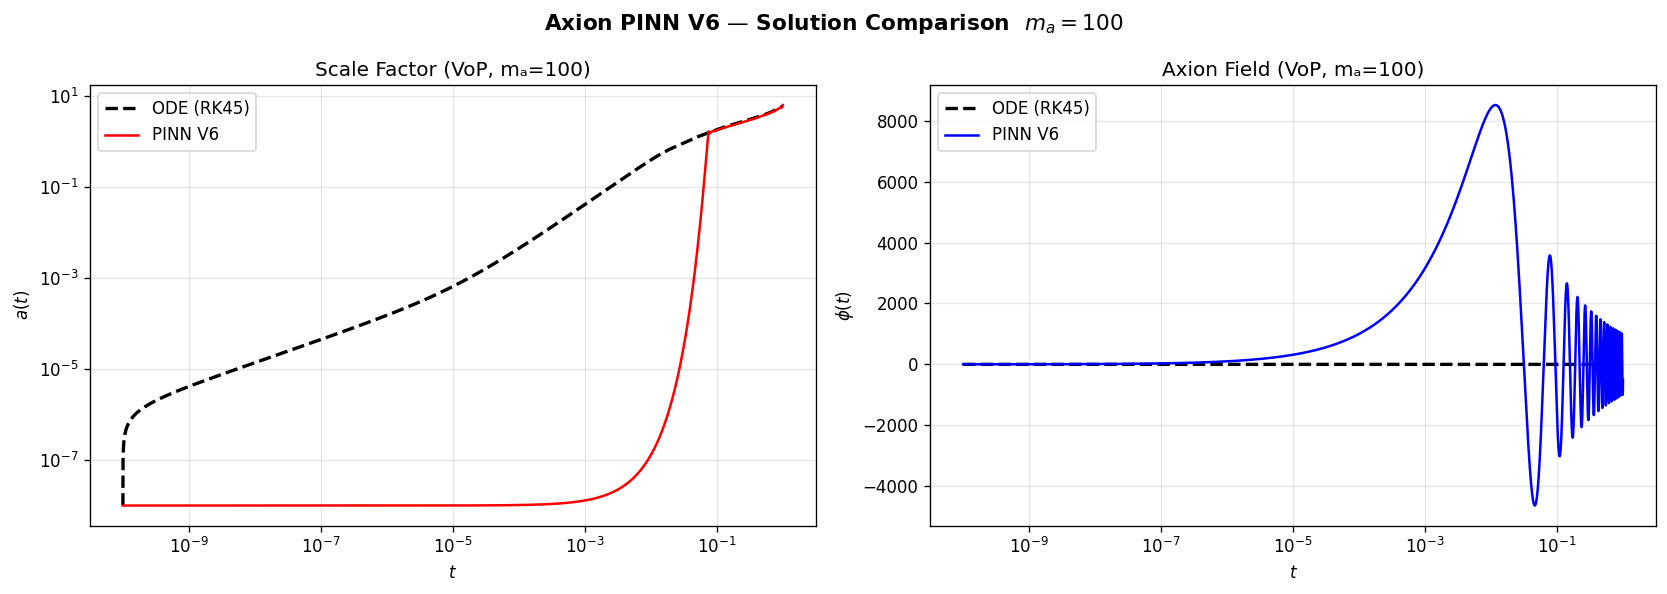

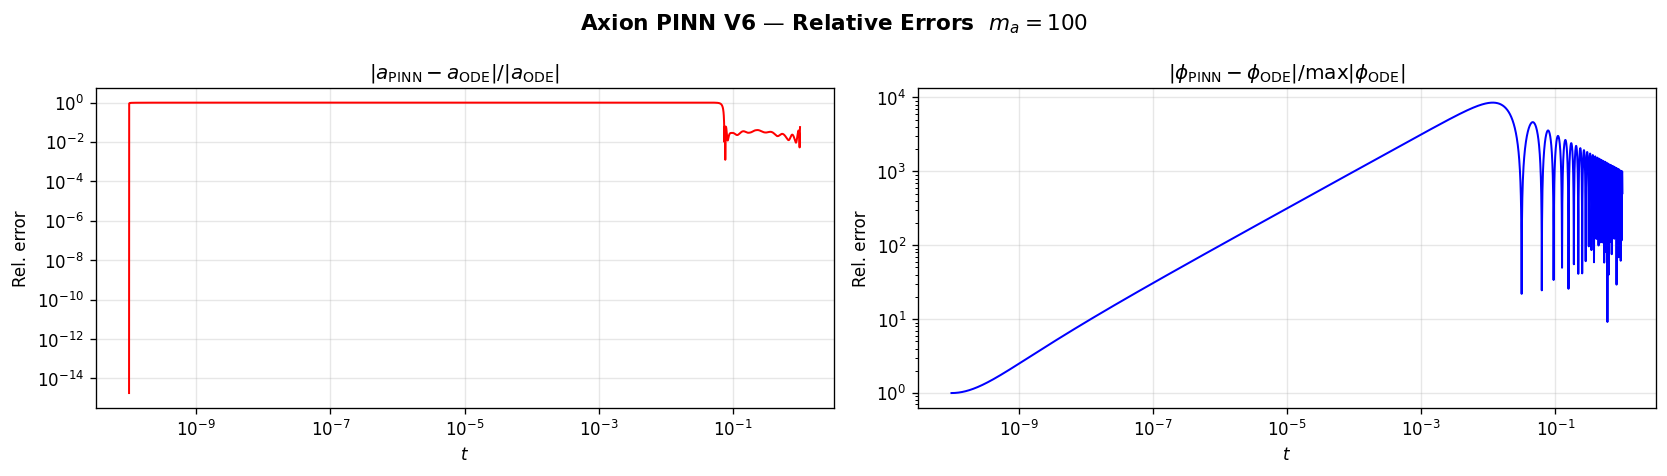

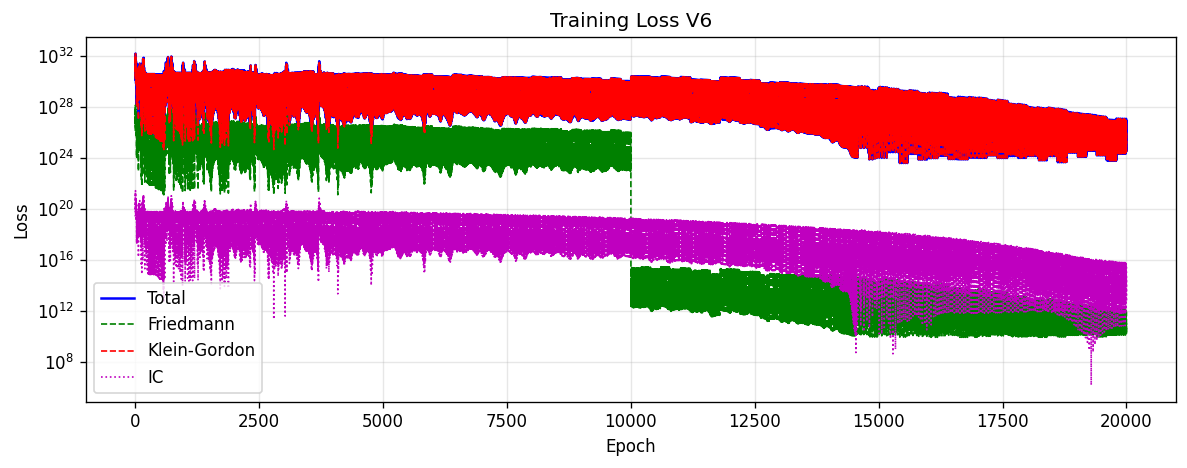


  V6 — Error Metrics
  a(t)  : max_rel=1.000e+00   mean_rel=8.863e-01
  φ(t)  : max_rel=8.512e+03  mean_rel=1.404e+03
  a(t0) : PINN=1.0000e-08  ODE=1.0000e-08  true=1.0000e-08
  φ(t0) : PINN=2.000061  ODE=1.000000  true=1.000000


In [20]:
a_v6, phi_v6 = evaluate_v6(
    solver_v6, sol_ref, PARAMS,
    save_dir='results_v6',
    tag=f'VoP, mₐ={PARAMS["ma"]:.0f}',
)


---
## V5 vs V6 Comparative Analysis

This cell loads V5 results (if available) and compares error metrics side-by-side.


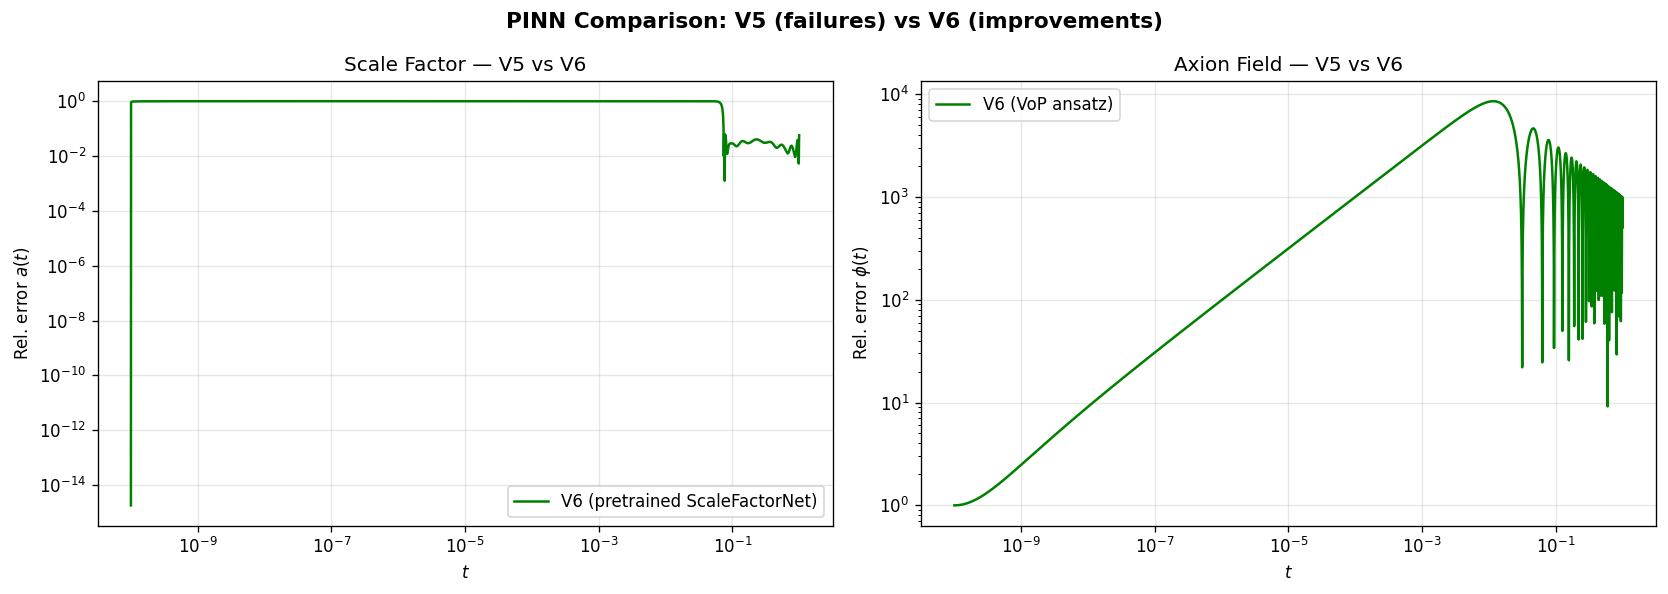

Saved: results_v6\comparison_v5_v6.png
V6 predictions saved to results_v6/


In [21]:
def compare_versions(sol, a_v5=None, phi_v5=None,
                      a_v6=None, phi_v6=None, save_dir='results_v6'):
    """
    Side-by-side comparison of V5 and V6 relative errors.
    Pass None for a version if not available.
    """
    t_np    = sol.t
    a_ref   = sol.y[0]
    phi_ref = sol.y[1]
    eps     = 1e-30

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

    ax = axes[0]
    if a_v5 is not None:
        rel_v5 = np.abs(a_v5 - a_ref) / (np.abs(a_ref) + eps)
        ax.loglog(t_np, rel_v5, 'r--', lw=1.5, alpha=0.8, label='V5 (direct MLP, no pretrain)')
    if a_v6 is not None:
        rel_v6 = np.abs(a_v6 - a_ref) / (np.abs(a_ref) + eps)
        ax.loglog(t_np, rel_v6, 'g-',  lw=1.5, label='V6 (pretrained ScaleFactorNet)')
    ax.set(xlabel='$t$', ylabel='Rel. error $a(t)$',
           title='Scale Factor — V5 vs V6')
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1]
    phi_scale = np.abs(phi_ref).max() + eps
    if phi_v5 is not None:
        rel_v5 = np.abs(phi_v5 - phi_ref) / phi_scale
        ax.loglog(t_np, rel_v5, 'r--', lw=1.5, alpha=0.8, label='V5 (sin-MLP, trivial collapse)')
    if phi_v6 is not None:
        rel_v6 = np.abs(phi_v6 - phi_ref) / phi_scale
        ax.loglog(t_np, rel_v6, 'g-',  lw=1.5, label='V6 (VoP ansatz)')
    ax.set(xlabel='$t$', ylabel='Rel. error $\\phi(t)$',
           title='Axion Field — V5 vs V6')
    ax.legend(); ax.grid(True, alpha=0.3)

    plt.suptitle('PINN Comparison: V5 (failures) vs V6 (improvements)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'comparison_v5_v6.png'),
                dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved: {os.path.join(save_dir, 'comparison_v5_v6.png')}")


# ── Load V5 results if they exist ────────────────────────────────────────────
# If you've already run V5 (Axion_PINN_V5.ipynb), you can load a_pred/phi_pred here.
# Here we load from the saved ODE grid matching our current sol_ref.
_v5_a_path   = os.path.join('results_v5', 'a_pred_v5.npy')
_v5_phi_path = os.path.join('results_v5', 'phi_pred_v5.npy')

a_v5_loaded   = np.load(_v5_a_path)   if os.path.exists(_v5_a_path)   else None
phi_v5_loaded = np.load(_v5_phi_path) if os.path.exists(_v5_phi_path) else None

compare_versions(sol_ref,
                  a_v5=a_v5_loaded, phi_v5=phi_v5_loaded,
                  a_v6=a_v6,         phi_v6=phi_v6)

# ── Save V6 predictions for future comparison ─────────────────────────────────
np.save('results_v6/a_pred_v6.npy',   a_v6)
np.save('results_v6/phi_pred_v6.npy', phi_v6)
print("V6 predictions saved to results_v6/")
